# Benchmark

**AI was used in the making of this notebook**


The data is taken from the UK/ Korea exports over the past 27 years. Hence due to it being a very niche area it was hard to find a paper that provides an exact benchmark. Hence the closest alternative was the AMRO Working Paper on "Nowcasting ASEAN+3 Goods Exports: Bridge and Machine Learning Models and Shipping 'Big Data' ". This provides a valuable benchmark to compare the results of the model against due to the paper's rigorous experimentation process of testing 53 models for each country it was testing for.

https://amro-asia.org/wp-content/uploads/2024/06/AMRO-Working-Paper-2024_12June2024.pdf

*Key Takeaways*
- Additional data like crude oil prices and freight rate where shown to improve RMSE score of models hence this is something that will also be reflected
- The paper's out-of-sample evaluation uses an expanding-window cross-validation setup which will also be used for our forecasting

# Data cleaning and processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
import torch
import torch.nn as nn
from dataclasses import field
from collections.abc import Callable
import yfinance
from sklearn.model_selection import TimeSeriesSplit

In [2]:
RAW_CSV_PATH = '/content/series-270726.csv'
df = pd.read_csv(RAW_CSV_PATH)
df.tail()

,Title,Trade in Goods: South Korea: Total: Exports: BOP: CP: SA
501,2026 JAN,399
502,2026 FEB,287
503,2026 MAR,397
504,2026 APR,375
505,2026 MAY,357


In [3]:
def load_raw_series(path: str = RAW_CSV_PATH):
    df_temp = pd.read_csv(RAW_CSV_PATH)
    value_col_name = df_temp.columns[1]
    df_temp = df_temp.rename(columns={'Title': 'period', value_col_name: 'value'})
    df_temp['value'] = pd.to_numeric(df_temp['value'], errors='coerce')
    df_temp = df_temp.dropna(subset=['value'])
    monthly_pattern = r'^\d{4} (JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$'
    df_temp = df_temp[df_temp['period'].astype(str).str.match(monthly_pattern)]
    df_temp["period"] = pd.to_datetime(df_temp["period"], format='%Y %b')
    df_temp = df_temp.set_index("period").sort_index()
    df = df_temp["value"].astype(float)
    df.index.name = "date"
    df.name = "exports_gbp_m"
    df = df.asfreq("MS")
    return df

#formating the date column

In [4]:
LAG_MONTHS = (1, 2, 3, 6, 12)
ROLL_WINDOWS = (3, 6, 12)
def _add_lag_and_rolling_features(y: pd.DataFrame, df: pd.DataFrame) -> pd.DataFrame:
    shifted = y.shift(1)

    for lag in LAG_MONTHS:
        df[f"lag_{lag}"] = y.shift(lag)

    for win in ROLL_WINDOWS:
        df[f"roll_mean_{win}"] = shifted.rolling(win, min_periods=win).mean()
        df[f"roll_std_{win}"] = shifted.rolling(win, min_periods=win).std()

    df["yoy_diff"] = shifted - y.shift(13)

    return df

#adding lagged features as well as a moving average and a standard deviation to check for voltility

In [5]:
def _add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    month = df.index.month
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)
    return df

#adding circular calendar features to allow the model to pick up more information from calendar data

In [6]:
OIL_PATH = '/content/brent-monthly.csv'
def _add_oil_price(df: pd.DataFrame) -> pd.DataFrame:
    oil_price = pd.read_csv(OIL_PATH)

    oil_price["Date"] = pd.to_datetime(oil_price["Date"])

    oil_price = (
        oil_price
        .set_index("Date")
        .sort_index()
    )

    df = df.copy()

    df_month = df.index.to_period("M")
    oil_price.index = oil_price.index.to_period("M")
    df["oil_price"] = df_month.map(oil_price.iloc[:, 0])
    df["oil_price"] = df["oil_price"].shift(1)

    return df

#as mentioned above the oil price data has been shown to improve model accuracy
#it has also been shifted by 1 month to prevent look forward bias

In [7]:
SHIP_PATH = '/content/TSIFRGHT.csv'
def _add_shipping_price(df: pd.DataFrame) -> pd.DataFrame:
    ship_price = pd.read_csv(SHIP_PATH)

    ship_price["Date"] = pd.to_datetime(ship_price["observation_date"])

    ship_price = (
        ship_price
        .set_index("Date")
        .sort_index()
    )

    df = df.copy()

    df_month = df.index.to_period("M")
    ship_price.index = ship_price.index.to_period("M")
    df["ship_price"] = df_month.map(ship_price.iloc[:, 1])
    df["ship_price"] = df["ship_price"].shift(1)
    return df
#similar to oil price

In [8]:
def build_feature_matrix(y_log: pd.DataFrame) -> pd.DataFrame:
    df = pd.DataFrame(index=y_log.index)
    df = _add_calendar_features(df)
    df = _add_lag_and_rolling_features(y_log, df)
    df = _add_oil_price(df)
    df = _add_shipping_price(df)
    return df
# actually adding all the features into the training dataframe

In [9]:
raw = load_raw_series(RAW_CSV_PATH)
y_log = np.log(raw)
y_log.name = "log_exports"

features = build_feature_matrix(y_log)
feature_names = list(features.columns)

warmup = max(12, max(LAG_MONTHS), max(ROLL_WINDOWS) + 1)

valid_index = features.dropna().index
valid_index = valid_index[valid_index >= features.index[warmup]]
features = features.loc[valid_index]
target = y_log.loc[valid_index]
raw = raw.loc[valid_index]
y_log = y_log.loc[valid_index]

print(f"Features: {feature_names}")

#applying log to the target data to scale it for the model
#warmup ensure moving average has sufficient data for training


Features: ['month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'yoy_diff', 'oil_price', 'ship_price']


In [10]:
features.shape, target.shape, raw.shape, y_log.shape

((316, 16), (316,), (316,), (316,))

# Visualising the data

<Axes: xlabel='date'>

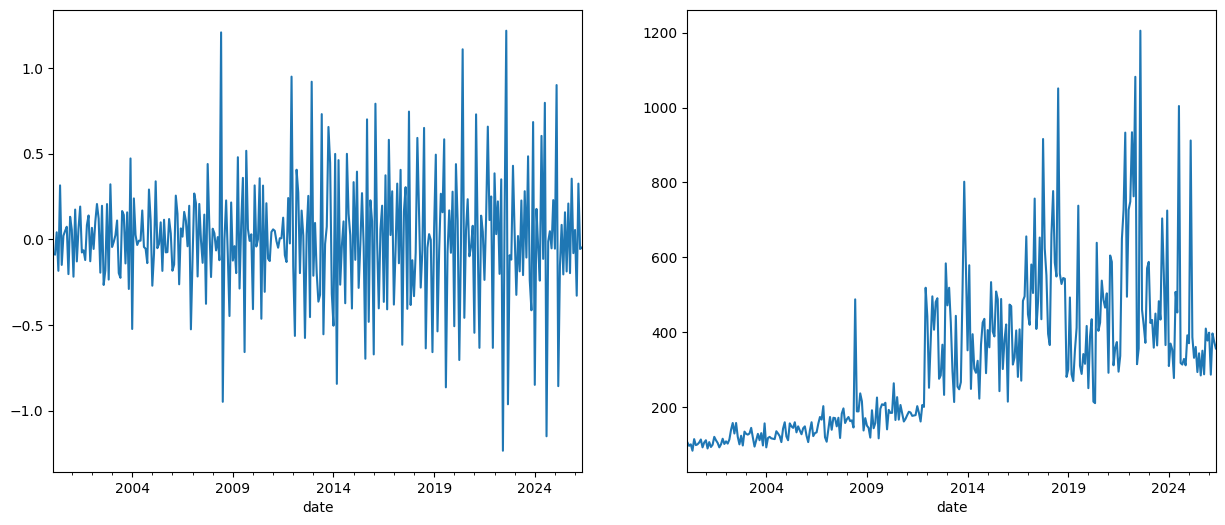

In [11]:
plt.figure(figsize=(15, 6))
plt.subplot(121)
(y_log - y_log.shift(1)).plot()
plt.subplot(122)
raw.plot()

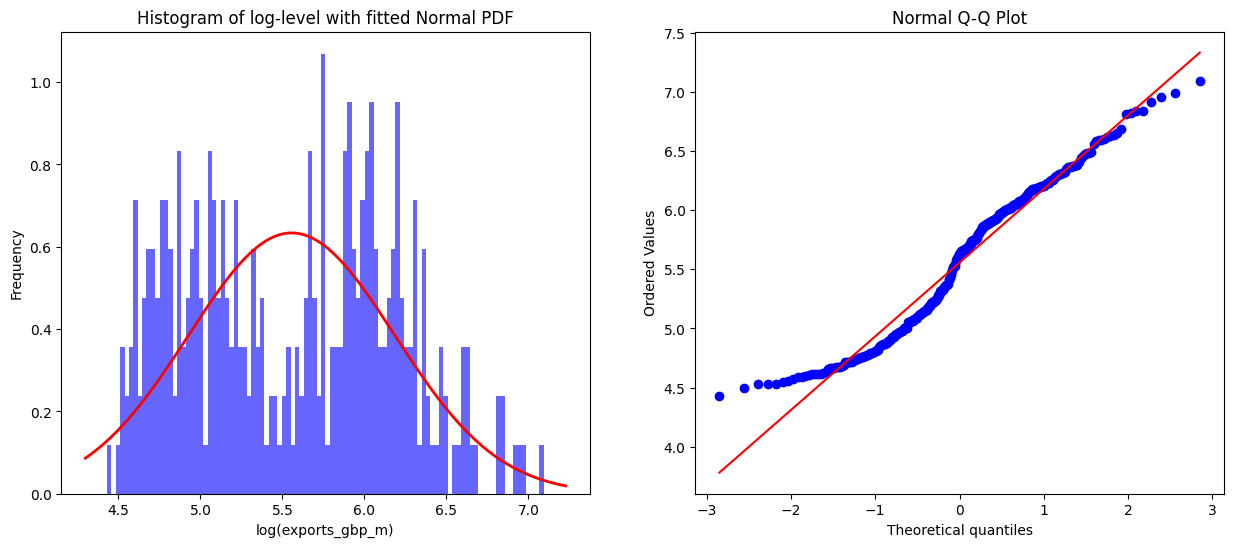

In [12]:
plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.hist(y_log, bins=100, density=True, alpha=0.6, color='b')
plt.xlabel('log(exports_gbp_m)')
plt.ylabel('Frequency')
x_min, x_max = plt.xlim()
x = np.linspace(x_min, x_max, 100)
mu = np.mean(y_log)
sigma = np.std(y_log)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r', linewidth=2)
plt.title('Histogram of log-level with fitted Normal PDF')

plt.subplot(122)
stats.probplot(y_log, dist='norm', plot=plt)
plt.title('Normal Q-Q Plot')
plt.show()

In [13]:
result = adfuller(raw)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -1.8038266526709708
p-value: 0.3785635286323878
Critical Values:
   1%: -3.451973573620699
   5%: -2.8710633193086648
   10%: -2.5718441306100512


In [14]:
result = stats.jarque_bera(raw)
print(f"JB Statistic: {result.statistic:.4f}")
print(f"P-value:      {result.pvalue:.4f}")

JB Statistic: 142.4817
P-value:      0.0000


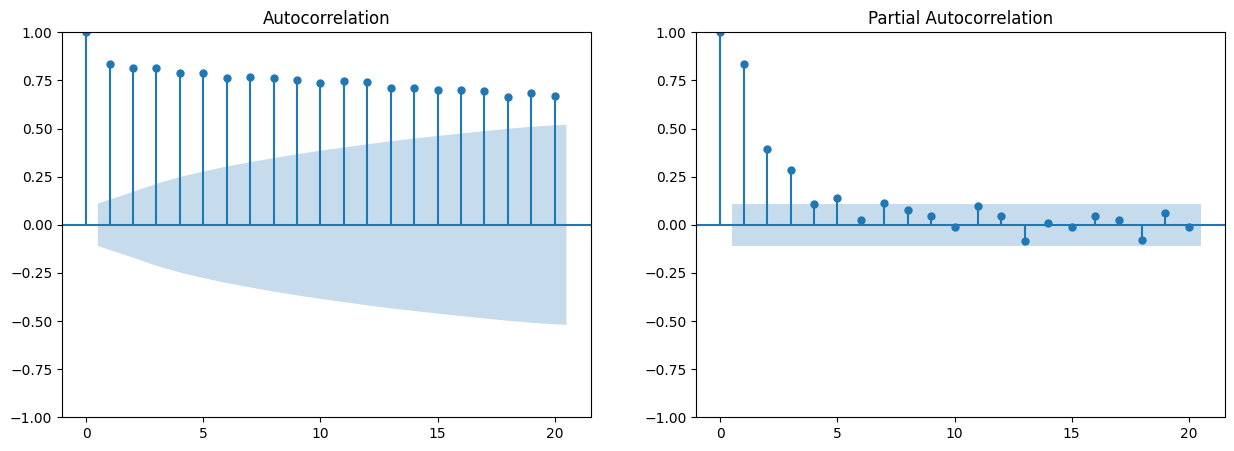

In [15]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
plot_acf(y_log, lags=20, ax=ax[0])
plot_pacf(y_log, lags=20, ax=ax[1])
plt.show()

## Findings

1) The histogram of logged data with a noraml probability distribution shows how the data is seasonal and non-normal
2) The data on the Q-Q plot shows a S-pattern that shows
3)  As seen from the results of the Augmented Dickey-Fuller (ADF) test and the Jarque-Bera Test the data we are working with is non-stationary, due to not being able to
reject the null hypothesis that there is a unit root.
4) From the ACF and PACF plots we can see that the data shows strong trend as the ACF decays very slowly, Furthermore the high autocorrelation at lag 12 shows that there may be annual seasonality



Hence a model like the Seasonal Autoregressive Integrated Moving Average with Exogenous Regressors (SARIMA) would be highly effective in forecasting such data, especially considering the additional features added like oil and freight prices, as seen from literature:

(https://www.academia.edu/125547329/Comparing_the_Effectiveness_of_ARIMA_and_SARIMA_Models_in_Forecasting_Seasonal_Energy_Consumption_A_Case_Study).


# Models

In [16]:
class NaiveForecaster:
    def fit(self, y_log_train: pd.Series, X_train: pd.DataFrame = None):
        self.last_value_ = y_log_train.iloc[-1]
        return self

    def predict(self, steps: int, y_log_history: pd.Series, X_future: pd.DataFrame = None) -> np.ndarray:
        return np.full(steps, y_log_history.iloc[-1])


class SeasonalNaiveForecaster:
    def fit(self, y_log_train: pd.Series, X_train: pd.DataFrame = None):
        return self

    def predict(self, steps: int, y_log_history: pd.Series, X_future: pd.DataFrame = None) -> np.ndarray:
        out = np.empty(steps)
        for h in range(steps):
            out[h] = y_log_history.iloc[-12 + (h % 12)] if len(y_log_history) >= 12 else y_log_history.iloc[-1]
        return out


#Considering the data showing seasonality especially at lag 12, rather than just the reguale naive forecast of lagging the data by 1, seasonl forecast has also been included.

In [17]:
class SarimaForecaster:
    def __init__(self, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)):
        self.order = order
        self.seasonal_order = seasonal_order

    def fit(self, y_log_train: pd.Series, X_train: pd.DataFrame = None):
        self.model_ = SARIMAX(
            y_log_train, order=self.order, seasonal_order=self.seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(
            disp=False,
            maxiter=1000
            )
        self.fittedvalues_ = self.model_.fittedvalues
        self._last_index = y_log_train.index[-1]
        return self

    def _extended_state_and_fitted(self, y_log_history: pd.Series):
        """Append any observations beyond the fit sample (without
        refitting) and return (state, fitted_values_over_full_history).

        Safe to call repeatedly: it recomputes the append from
        self.model_/self.fittedvalues_ each time, so it works whether
        y_log_history is exactly the training data, one fold ahead of
        it (retrain_every > 1), or many recursive forecast blocks ahead
        of it (chained multi-block forecasting) -- the fitted series
        returned always spans the full y_log_history index, which is
        what the Hybrid model's residual channel needs.
        """
        if y_log_history.index[-1] != self._last_index:
            new_obs = y_log_history.loc[y_log_history.index > self._last_index]
            new_obs = new_obs.rename(self.model_.model.endog_names)
            state = self.model_.append(new_obs, refit=False)
            fitted = pd.concat([self.fittedvalues_, state.fittedvalues.loc[new_obs.index]])
            return state, fitted
        return self.model_, self.fittedvalues_

    def predict(self, steps: int, y_log_history: pd.Series = None, X_future: pd.DataFrame = None) -> np.ndarray:
        if y_log_history is not None and y_log_history.index[-1] != self._last_index:
            state, _ = self._extended_state_and_fitted(y_log_history)
            return np.asarray(state.forecast(steps=steps))
        return np.asarray(self.model_.forecast(steps=steps))

In [18]:
class RidgeForecaster:
    def __init__(self, alphas=np.logspace(-3, 3, 25)):
        self.alphas = alphas

    def fit(self, y_log_train: pd.Series, X_train: pd.DataFrame):
        self.scaler_ = StandardScaler().fit(X_train.values)
        Xs = self.scaler_.transform(X_train.values)
        tscv = TimeSeriesSplit(n_splits=5)
        self.model_ = RidgeCV(alphas=self.alphas, cv=tscv).fit(Xs, y_train := y_log_train.values)
        self.feature_names_ = list(X_train.columns)
        return self

    def predict(self, steps: int, y_log_history: pd.Series, X_future: pd.DataFrame) -> np.ndarray:
        # X_future carries calendar features (known in advance) for the H
        # forecast months; lag/rolling features get filled in recursively.
        history = y_log_history.copy()
        preds = []
        for h in range(steps):
            future_date = X_future.index[h]
            extended = pd.concat([history, pd.Series([np.nan], index=[future_date])])
            feat_row = build_feature_matrix(extended).loc[[future_date]]
            feat_row[["month_sin", "month_cos"]] = X_future.loc[[future_date], ["month_sin", "month_cos"]]
            Xs = self.scaler_.transform(feat_row[self.feature_names_].values)
            yhat = float(self.model_.predict(Xs)[0])
            preds.append(yhat)
            history.loc[future_date] = yhat
        return np.asarray(preds)

In [19]:
class LassoForecaster:
    """Lasso-regularised linear forecaster, mirrors RidgeForecaster but
    swaps RidgeCV for LassoCV. L1 penalty drives some lag/calendar
    feature coefficients exactly to zero, so this doubles as a rough
    feature-selection check against the Ridge fit above.
    """
    def __init__(self, alphas=np.logspace(-4, 1, 30), max_iter=10000):
        self.alphas = alphas
        self.max_iter = max_iter

    def fit(self, y_log_train: pd.Series, X_train: pd.DataFrame):
        self.scaler_ = StandardScaler().fit(X_train.values)
        Xs = self.scaler_.transform(X_train.values)
        tscv = TimeSeriesSplit(n_splits=5)
        self.model_ = LassoCV(
            alphas=self.alphas, cv=tscv, max_iter=self.max_iter
        ).fit(Xs, y_train := y_log_train.values)
        self.feature_names_ = list(X_train.columns)
        return self

    def predict(self, steps: int, y_log_history: pd.Series, X_future: pd.DataFrame) -> np.ndarray:
        # Same recursive scheme as RidgeForecaster.predict: lag/rolling
        # features get filled in recursively, calendar features are
        # known in advance and copied straight from X_future.
        history = y_log_history.copy()
        preds = []
        for h in range(steps):
            future_date = X_future.index[h]
            extended = pd.concat([history, pd.Series([np.nan], index=[future_date])])
            feat_row = build_feature_matrix(extended).loc[[future_date]]
            feat_row[["month_sin", "month_cos"]] = X_future.loc[[future_date], ["month_sin", "month_cos"]]
            Xs = self.scaler_.transform(feat_row[self.feature_names_].values)
            yhat = float(self.model_.predict(Xs)[0])
            preds.append(yhat)
            history.loc[future_date] = yhat
        return np.asarray(preds)


In [20]:
class LSTMNet(nn.Module):

    def __init__(self, n_input_features: int, hidden_size: int = 32,
                 num_layers: int = 1, horizon: int = 6, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_input_features, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, horizon),
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]
        return self.head(last_hidden)


In [21]:
class LSTMForecaster:
    """Wraps LSTMNet with windowing, scaling, training loop (Huber loss,
    Adam, early stopping on an internal validation split), and a predict()
    that matches the shared forecaster interface."""

    def __init__(self, lookback: int = 24, horizon: int = 6, hidden_size: int = 32,
                 num_layers: int = 1, dropout: float = 0.2, lr: float = 1e-3,
                 weight_decay: float = 1e-4, max_epochs: int = 300,
                 patience: int = 20, batch_size: int = 16, seed: int = 0,
                 device: str = "cpu"):
        self.lookback = lookback
        self.horizon = horizon
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.max_epochs = max_epochs
        self.patience = patience
        self.batch_size = batch_size
        self.seed = seed
        self.device = device

    def _make_windows(self, y_log: pd.Series, X_calendar: pd.DataFrame):
        """Convert timeseries to overlapping input/target windows for LSTM."""
        values = y_log.values
        cal = X_calendar[["month_sin", "month_cos"]].values
        n = len(values)
        xs, ys = [], []
        for t in range(self.lookback, n - self.horizon + 1):
            seq_vals = values[t - self.lookback: t].reshape(-1, 1)
            seq_cal = cal[t - self.lookback: t]
            xs.append(np.hstack([seq_vals, seq_cal]))
            ys.append(values[t: t + self.horizon])
        return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

    def fit(self, y_log_train: pd.Series, X_train: pd.DataFrame):
        torch.manual_seed(self.seed)

        self.mu_ = float(y_log_train.mean())
        self.sigma_ = float(y_log_train.std() + 1e-8)

        y_scaled = (y_log_train - self.mu_) / self.sigma_
        X_all, y_all = self._make_windows(y_scaled, X_train)

        if len(X_all) < 20:
            raise ValueError(
                f"Only {len(X_all)} training windows available; need more history "
                f"before the first LSTM fold (lookback={self.lookback}, horizon={self.horizon})."
            )

        n_val = max(8, int(0.15 * len(X_all)))
        X_tr, y_tr = X_all[:-n_val], y_all[:-n_val]
        X_val, y_val = X_all[-n_val:], y_all[-n_val:]

        Xtr_t, ytr_t = torch.tensor(X_tr), torch.tensor(y_tr)
        Xval_t, yval_t = torch.tensor(X_val), torch.tensor(y_val)

        n_features = X_tr.shape[-1]
        self.model_ = LSTMNet(
            n_input_features=n_features, horizon=self.horizon, hidden_size=self.hidden_size,
            num_layers=self.num_layers, dropout=self.dropout,
        ).to(self.device)

        opt = torch.optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        loss_fn = nn.SmoothL1Loss()

        best_val, best_state, patience_left = float("inf"), None, self.patience
        n_train = Xtr_t.shape[0]

        for epoch in range(self.max_epochs):
            self.model_.train()
            perm = torch.randperm(n_train)
            for i in range(0, n_train, self.batch_size):
                idx = perm[i: i + self.batch_size]
                xb = Xtr_t[idx].to(self.device)
                yb = ytr_t[idx].to(self.device)
                opt.zero_grad()
                pred = self.model_(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()

            self.model_.eval()
            with torch.no_grad():
                val_pred = self.model_(Xval_t.to(self.device))
                val_loss = loss_fn(val_pred, yval_t.to(self.device)).item()

            if val_loss < best_val - 1e-5:
                best_val = val_loss
                best_state = {k: v.clone() for k, v in self.model_.state_dict().items()}
                patience_left = self.patience
            else:
                patience_left -= 1
                if patience_left <= 0:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)
        self.model_.eval()

        self._y_log_train = y_log_train
        return self

    def predict(self, steps: int, y_log_history: pd.Series, X_future: pd.DataFrame) -> np.ndarray:
        if steps > self.horizon:
            raise ValueError(f"LSTMForecaster trained for horizon={self.horizon}, "
                             f"requested steps={steps}.")

        y_scaled = (y_log_history - self.mu_) / self.sigma_

        # Prepare the input for the LSTM model using the last 'lookback' values
        tail_vals = y_scaled.values[-self.lookback:].reshape(-1, 1)

        # Get calendar features for the historical window
        hist_cal = pd.DataFrame(index=y_log_history.index[-self.lookback:])
        month = hist_cal.index.month
        hist_cal["month_sin"] = np.sin(2 * np.pi * month / 12)
        hist_cal["month_cos"] = np.cos(2 * np.pi * month / 12)

        x = np.hstack([tail_vals, hist_cal.values]).astype(np.float32)
        x_t = torch.tensor(x).unsqueeze(0).to(self.device)  # Add batch dimension

        with torch.no_grad():
            pred_scaled = self.model_(x_t).cpu().numpy().ravel()[:steps]

        pred_log = (pred_scaled * self.sigma_) + self.mu_
        return pred_log

In [22]:
class ResidualLSTMNet(nn.Module):
    """Encoder LSTM over [log-level, month_sin, month_cos, sarima_residual]
    history, with the SARIMA forecast path for the target horizon
    concatenated into the head so the correction can be horizon-specific."""

    def __init__(self, n_input_features: int, horizon: int, hidden_size: int = 32,
                 num_layers: int = 1, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_input_features, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size + horizon, hidden_size // 2),  # + SARIMA forecast path
            nn.ReLU(),
            nn.Linear(hidden_size // 2, horizon),
        )

    def forward(self, x, sarima_target_scaled):
        _, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]
        combined = torch.cat([last_hidden, sarima_target_scaled], dim=-1)
        return self.head(combined)  # predicted RESIDUAL, scaled



In [23]:
class HybridSarimaLSTMForecaster:
    """SARIMA + LSTM residual-correction hybrid. Same external interface as
    the other forecasters, but internally fits its own SARIMA model to
    generate the fitted-value / forecast features described above."""

    def __init__(self, lookback: int = 24, horizon: int = 6, hidden_size: int = 32,
                 num_layers: int = 1, dropout: float = 0.2, lr: float = 1e-3,
                 weight_decay: float = 1e-4, max_epochs: int = 300,
                 patience: int = 20, batch_size: int = 16, seed: int = 0,
                 device: str = "cpu", sarima_order=(1, 1, 1), sarima_seasonal_order=(1, 1, 1, 12)):
        self.lookback = lookback
        self.horizon = horizon
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.max_epochs = max_epochs
        self.patience = patience
        self.batch_size = batch_size
        self.seed = seed
        self.device = device
        self.sarima_order = sarima_order
        self.sarima_seasonal_order = sarima_seasonal_order

    def _make_windows(self, y_log: pd.Series, sarima_fitted: pd.Series, X_calendar: pd.DataFrame):
        """As LSTMForecaster._make_windows, plus a 4th input channel
        (historical SARIMA residual) and a per-window SARIMA target vector
        used as the residual-correction target and as head conditioning."""
        values = y_log.values
        resid = (y_log - sarima_fitted).values          # history channel
        sarima_vals = sarima_fitted.values                # proxy for "future" SARIMA path
        cal = X_calendar[["month_sin", "month_cos"]].values
        n = len(values)
        xs, sarima_targets, ys = [], [], []
        for t in range(self.lookback, n - self.horizon + 1):
            seq_vals = values[t - self.lookback: t].reshape(-1, 1)
            seq_resid = resid[t - self.lookback: t].reshape(-1, 1)
            seq_cal = cal[t - self.lookback: t]
            xs.append(np.hstack([seq_vals, seq_cal, seq_resid]))

            sarima_target = sarima_vals[t: t + self.horizon]      # SARIMA's "opinion" of the target months
            actual_target = values[t: t + self.horizon]
            sarima_targets.append(sarima_target)
            ys.append(actual_target - sarima_target)              # residual to be learned

        return (np.asarray(xs, dtype=np.float32),
                np.asarray(sarima_targets, dtype=np.float32),
                np.asarray(ys, dtype=np.float32))

    def fit(self, y_log_train: pd.Series, X_train: pd.DataFrame):
        torch.manual_seed(self.seed)

        #internal SARIMA fit, purely to generate features
        self.sarima_ = SarimaForecaster(order=self.sarima_order, seasonal_order=self.sarima_seasonal_order)
        self.sarima_.fit(y_log_train)
        sarima_fitted = self.sarima_.fittedvalues_.reindex(y_log_train.index).fillna(0.0)

        self.mu_ = float(y_log_train.mean())
        self.sigma_ = float(y_log_train.std() + 1e-8)

        y_scaled = (y_log_train - self.mu_) / self.sigma_
        sarima_scaled = (sarima_fitted - self.mu_) / self.sigma_

        X_all, sarima_tgt_all, y_all = self._make_windows(y_scaled, sarima_scaled, X_train)
        if len(X_all) < 20:
            raise ValueError(
                f"Only {len(X_all)} training windows available; need more history "
                f"before the first hybrid-LSTM fold (lookback={self.lookback}, horizon={self.horizon})."
            )

        n_val = max(8, int(0.15 * len(X_all)))
        X_tr, S_tr, y_tr = X_all[:-n_val], sarima_tgt_all[:-n_val], y_all[:-n_val]
        X_val, S_val, y_val = X_all[-n_val:], sarima_tgt_all[-n_val:], y_all[-n_val:]

        Xtr_t, Str_t, ytr_t = torch.tensor(X_tr), torch.tensor(S_tr), torch.tensor(y_tr)
        Xval_t, Sval_t, yval_t = torch.tensor(X_val), torch.tensor(S_val), torch.tensor(y_val)

        n_features = X_tr.shape[-1]
        self.model_ = ResidualLSTMNet(
            n_input_features=n_features, horizon=self.horizon, hidden_size=self.hidden_size,
            num_layers=self.num_layers, dropout=self.dropout,
        ).to(self.device)

        opt = torch.optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        loss_fn = nn.SmoothL1Loss()

        best_val, best_state, patience_left = float("inf"), None, self.patience
        n_train = Xtr_t.shape[0]

        for epoch in range(self.max_epochs):
            self.model_.train()
            perm = torch.randperm(n_train)
            for i in range(0, n_train, self.batch_size):
                idx = perm[i: i + self.batch_size]
                xb = Xtr_t[idx].to(self.device)
                sb = Str_t[idx].to(self.device)
                yb = ytr_t[idx].to(self.device)
                opt.zero_grad()
                pred = self.model_(xb, sb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()

            self.model_.eval()
            with torch.no_grad():
                val_pred = self.model_(Xval_t.to(self.device), Sval_t.to(self.device))
                val_loss = loss_fn(val_pred, yval_t.to(self.device)).item()

            if val_loss < best_val - 1e-5:
                best_val = val_loss
                best_state = {k: v.clone() for k, v in self.model_.state_dict().items()}
                patience_left = self.patience
            else:
                patience_left -= 1
                if patience_left <= 0:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)
        self.model_.eval()

        # Cache history needed at predict() time.
        self._y_log_train = y_log_train
        self._sarima_fitted_train = sarima_fitted
        return self

    def predict(self, steps: int, y_log_history: pd.Series, X_future: pd.DataFrame) -> np.ndarray:
        if steps > self.horizon:
            raise ValueError(f"HybridSarimaLSTMForecaster trained for horizon={self.horizon}, "
                              f"requested steps={steps}.")
        sarima_state, sarima_fitted_extended = self.sarima_._extended_state_and_fitted(y_log_history)
        sarima_forecast = np.asarray(sarima_state.forecast(steps=steps))
        sarima_forecast_scaled = (sarima_forecast - self.mu_) / self.sigma_

        y_scaled = (y_log_history - self.mu_) / self.sigma_
        sarima_fitted_extended = sarima_fitted_extended.reindex(y_log_history.index)
        sarima_fitted_scaled = (sarima_fitted_extended - self.mu_) / self.sigma_
        resid_scaled = (y_scaled - sarima_fitted_scaled).values

        tail_vals = y_scaled.values[-self.lookback:].reshape(-1, 1)
        tail_resid = resid_scaled[-self.lookback:].reshape(-1, 1)

        hist_cal = pd.DataFrame(index=y_log_history.index[-self.lookback:])
        month = hist_cal.index.month
        hist_cal["month_sin"] = np.sin(2 * np.pi * month / 12)
        hist_cal["month_cos"] = np.cos(2 * np.pi * month / 12)

        x = np.hstack([tail_vals, hist_cal.values, tail_resid]).astype(np.float32)
        x_t = torch.tensor(x).unsqueeze(0).to(self.device)

        s_t = torch.tensor(sarima_forecast_scaled.astype(np.float32)).unsqueeze(0).to(self.device)
        if s_t.shape[1] < self.horizon:  # pad if steps < horizon
            pad = torch.zeros(1, self.horizon - s_t.shape[1])
            s_t = torch.cat([s_t, pad], dim=1)

        with torch.no_grad():
            resid_pred_scaled = self.model_(x_t, s_t).cpu().numpy().ravel()[:steps]

        pred_log = (sarima_forecast_scaled[:steps] + resid_pred_scaled) * self.sigma_ + self.mu_
        return pred_log

## Training

In [24]:
HORIZON = 6           # months forecast per fold
MIN_TRAIN = 180       # first training window: 15 years of monthly data
RETRAIN_EVERY = 1     # refitting every fold
LSTM_LOOKBACK = 24

In [25]:
from dataclasses import dataclass, field

@dataclass
class FoldResult:
    fold: int
    train_end: pd.Timestamp
    eval_dates: pd.DatetimeIndex
    y_true_log: np.ndarray
    y_pred_log: np.ndarray
    fit_seconds: float



@dataclass
class WalkForwardReport:
    model_name: str
    folds: list = field(default_factory=list)

    def to_frame(self) -> pd.DataFrame:
        rows = []
        for f in self.folds:
            for h, (date, yt, yp) in enumerate(zip(f.eval_dates, f.y_true_log, f.y_pred_log), start=1):
                rows.append({
                    "fold": f.fold, "date": date, "horizon": h,
                    "y_true_log": yt, "y_pred_log": yp,
                    "y_true": np.exp(yt), "y_pred": np.exp(yp),
                })
        return pd.DataFrame(rows)

    def metrics(self) -> dict:
        df = self.to_frame()
        err = df["y_true"] - df["y_pred"]
        pct_err = err / df["y_true"]
        log_err = df["y_true_log"] - df["y_pred_log"]
        return {
            "model": self.model_name,
            "n_forecasts": len(df),
            "rmse_gbp_m": float(np.sqrt((err ** 2).mean())),
            "mae_gbp_m": float(err.abs().mean()),
            "mape_pct": float((pct_err.abs().mean()) * 100),
            "rmse_log": float(np.sqrt((log_err ** 2).mean())),
        }

    def metrics_by_horizon(self) -> pd.DataFrame:
        df = self.to_frame()
        out = []
        for h, g in df.groupby("horizon"):
            err = g["y_true"] - g["y_pred"]
            pct_err = err / g["y_true"]
            out.append({
                "model": self.model_name, "horizon": h,
                "rmse_gbp_m": float(np.sqrt((err ** 2).mean())),
                "mape_pct": float(pct_err.abs().mean() * 100),
            })
        return pd.DataFrame(out)


def run_walk_forward(
    model_factory: Callable[[], object],
    y_log: pd.Series,
    X: pd.DataFrame,
    model_name: str,
    min_train: int,
    horizon: int = 6,
    step: int = None,
    retrain_every: int = 1,
) -> WalkForwardReport:
    """Runs expanding-window walk-forward evaluation for one forecaster.

    Parameters
    ----------
    model_factory : zero-arg callable returning a fresh, unfitted model
        instance implementing .fit(y_log_train, X_train) / .predict(steps, y_log_history, X_future)
    y_log, X : full-history target and feature matrix from data_pipeline.prepare_series()
    min_train : minimum number of months in the first training window
    horizon : months forecast (and evaluated) per fold
    step : months advanced between folds (default: horizon, i.e. non-overlapping)
    retrain_every : refit the model every N folds (1 = every fold)
    """
    step = horizon if step is None else step
    n = len(y_log)
    report = WalkForwardReport(model_name=model_name)

    model = None
    fold = 0
    train_end_idx = min_train
    while train_end_idx + horizon <= n:
        y_train = y_log.iloc[:train_end_idx]
        X_train = X.iloc[:train_end_idx]
        eval_dates = y_log.index[train_end_idx: train_end_idx + horizon]
        X_future = X.loc[eval_dates]
        y_true = y_log.iloc[train_end_idx: train_end_idx + horizon].values

        t0 = time.time()
        if model is None or fold % retrain_every == 0:
            model = model_factory()
            model.fit(y_train, X_train)
        fit_seconds = time.time() - t0

        y_pred = model.predict(steps=horizon, y_log_history=y_train, X_future=X_future)

        report.folds.append(FoldResult(
            fold=fold, train_end=y_train.index[-1], eval_dates=eval_dates,
            y_true_log=y_true, y_pred_log=np.asarray(y_pred), fit_seconds=fit_seconds,
        ))

        fold += 1
        train_end_idx += step

    return report

In [26]:
import time

def _new_ridge_forecaster_predict(self, steps: int, y_log_history: pd.Series, X_future: pd.DataFrame) -> np.ndarray:
    history = y_log_history.copy()
    preds = []
    for h in range(steps):
        future_date = X_future.index[h]
        extended = pd.concat([history, pd.Series([np.nan], index=[future_date])])
        feat_row = build_feature_matrix(extended).loc[[future_date]]
        feat_row[["month_sin", "month_cos"]] = X_future.loc[[future_date], ["month_sin", "month_cos"]]
        Xs = self.scaler_.transform(feat_row[self.feature_names_].values)
        yhat = float(self.model_.predict(Xs)[0])
        preds.append(yhat)
        history.loc[future_date] = yhat
    return np.asarray(preds)

RidgeForecaster.predict = _new_ridge_forecaster_predict

model_factories = {
    "Naive": lambda: NaiveForecaster(),
    "SeasonalNaive": lambda: SeasonalNaiveForecaster(),
    "SARIMA(1,1,1)(1,1,1)12": lambda: SarimaForecaster(),
    "Ridge (lag+calendar feats)": lambda: RidgeForecaster(),
    "Lasso (lag+calendar feats)": lambda: LassoForecaster(),
    "LSTM (encoder-decoder)": lambda: LSTMForecaster(
        lookback=LSTM_LOOKBACK, horizon=HORIZON, hidden_size=32,
        num_layers=1, dropout=0.2, lr=1e-3, weight_decay=1e-4,
        max_epochs=300, patience=20, batch_size=16,
    ),
    "Hybrid SARIMA+LSTM (residual)": lambda: HybridSarimaLSTMForecaster(
        lookback=LSTM_LOOKBACK, horizon=HORIZON, hidden_size=32,
        num_layers=1, dropout=0.2, lr=1e-3, weight_decay=1e-4,
        max_epochs=300, patience=20, batch_size=16,
    ),
}

X = features # Assign features to X

reports: dict[str, WalkForwardReport] = {}
for name, factory in model_factories.items():
    print(f"Running walk-forward CV: {name} ...")
    report = run_walk_forward(
        model_factory=factory, y_log=y_log, X=X, model_name=name,
        min_train=MIN_TRAIN, horizon=HORIZON, retrain_every=RETRAIN_EVERY,
    )
    reports[name] = report
    m = report.metrics()
    print(f"  folds={len(report.folds)}  RMSE=£{m['rmse_gbp_m']:.1f}m  "
          f"MAE=£{m['mae_gbp_m']:.1f}m  MAPE={m['mape_pct']:.1f}%")

Running walk-forward CV: Naive ...
  folds=22  RMSE=£299.7m  MAE=£217.4m  MAPE=48.9%
Running walk-forward CV: SeasonalNaive ...
  folds=22  RMSE=£260.4m  MAE=£198.5m  MAPE=43.2%
Running walk-forward CV: SARIMA(1,1,1)(1,1,1)12 ...
  folds=22  RMSE=£196.3m  MAE=£150.5m  MAPE=33.1%
Running walk-forward CV: Ridge (lag+calendar feats) ...
  folds=22  RMSE=£202.8m  MAE=£157.0m  MAPE=33.3%
Running walk-forward CV: Lasso (lag+calendar feats) ...
  folds=22  RMSE=£201.1m  MAE=£155.7m  MAPE=32.9%
Running walk-forward CV: LSTM (encoder-decoder) ...
  folds=22  RMSE=£202.1m  MAE=£141.1m  MAPE=27.3%
Running walk-forward CV: Hybrid SARIMA+LSTM (residual) ...
  folds=22  RMSE=£191.9m  MAE=£143.9m  MAPE=31.2%


# Results



=== Overall walk-forward metrics (all folds, h=1..6 pooled) ===
                               n_forecasts  rmse_gbp_m  mae_gbp_m  mape_pct  rmse_log
model                                                                                
Hybrid SARIMA+LSTM (residual)          132      191.95     143.90     31.16      0.37
SARIMA(1,1,1)(1,1,1)12                 132      196.28     150.46     33.11      0.38
Lasso (lag+calendar feats)             132      201.12     155.72     32.88      0.40
LSTM (encoder-decoder)                 132      202.07     141.06     27.26      0.37
Ridge (lag+calendar feats)             132      202.76     157.04     33.32      0.40
SeasonalNaive                          132      260.45     198.45     43.18      0.48
Naive                                  132      299.70     217.39     48.87      0.56

=== RMSE (£m) by forecast horizon (months ahead) ===
model    Hybrid SARIMA+LSTM (residual)  LSTM (encoder-decoder)  Lasso (lag+calendar feats)  Naive  Ridge (l

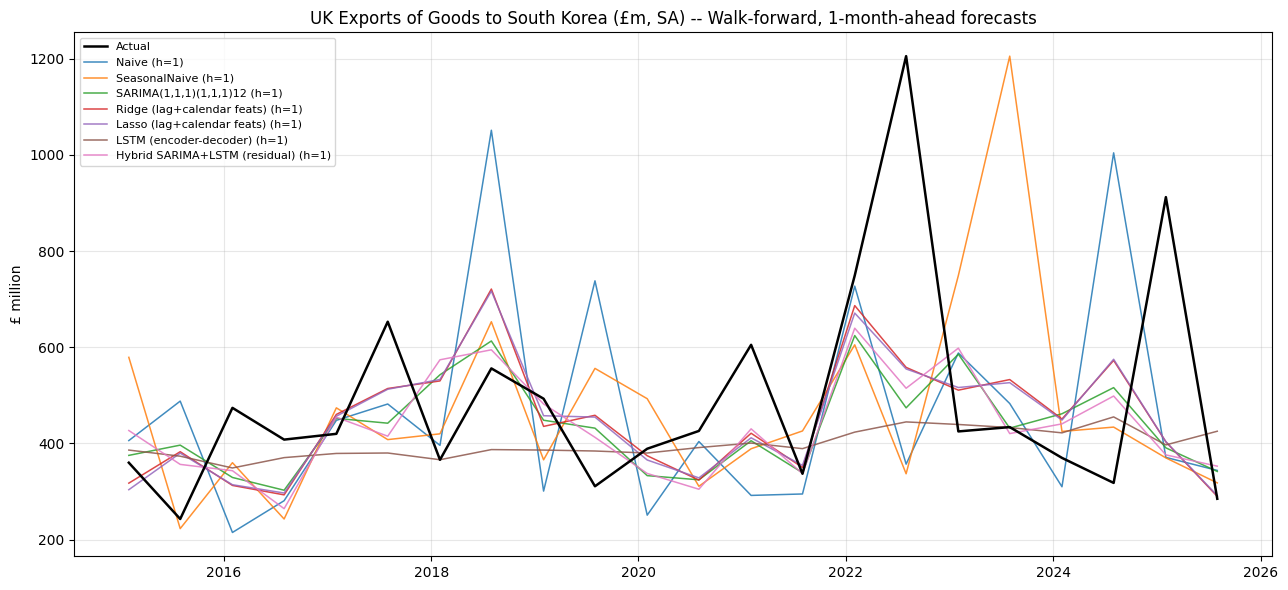

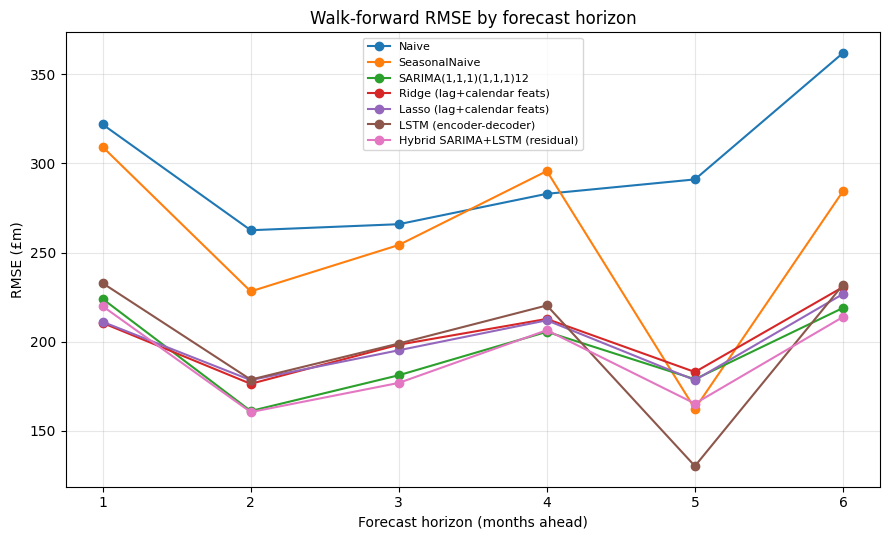

In [27]:
import os

# Overall comparison table
overall = pd.DataFrame([r.metrics() for r in reports.values()]).set_index("model")
overall = overall.sort_values("rmse_gbp_m")
print("\n=== Overall walk-forward metrics (all folds, h=1..%d pooled) ===" % HORIZON)
print(overall.to_string(float_format=lambda v: f"{v:,.2f}"))

#Metrics by horizon
by_h = pd.concat([r.metrics_by_horizon() for r in reports.values()], ignore_index=True)
pivot_rmse = by_h.pivot(index="horizon", columns="model", values="rmse_gbp_m")
print("\n=== RMSE (£m) by forecast horizon (months ahead) ===")
print(pivot_rmse.to_string(float_format=lambda v: f"{v:,.1f}"))

os.makedirs("outputs", exist_ok=True)
overall.to_csv("outputs/overall_metrics.csv")
by_h.to_csv("outputs/metrics_by_horizon.csv", index=False)

#Plot: actual vs. predicted
fig, ax = plt.subplots(figsize=(13, 6))
actual_plotted = False
for name, report in reports.items():
    df = report.to_frame()
    h1 = df[df["horizon"] == 1].sort_values("date")
    if not actual_plotted:
        ax.plot(h1["date"], h1["y_true"], color="black", lw=1.8, label="Actual", zorder=5)
        actual_plotted = True
    ax.plot(h1["date"], h1["y_pred"], lw=1.1, alpha=0.85, label=f"{name} (h=1)")

ax.set_title("UK Exports of Goods to South Korea (£m, SA) -- Walk-forward, 1-month-ahead forecasts")
ax.set_ylabel("£ million")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("outputs/walk_forward_h1_comparison.png", dpi=150)

#Plot: RMSE by horizon, all models
fig2, ax2 = plt.subplots(figsize=(9, 5.5))
for name in reports.keys():
    row = pivot_rmse[name]
    ax2.plot(row.index, row.values, marker="o", label=name)
ax2.set_xlabel("Forecast horizon (months ahead)")
ax2.set_ylabel("RMSE (£m)")
ax2.set_title("Walk-forward RMSE by forecast horizon")
ax2.set_xticks(range(1, HORIZON + 1))
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig("outputs/rmse_by_horizon.png", dpi=150)

print("\nSaved: outputs/overall_metrics.csv, outputs/metrics_by_horizon.csv, "
      "outputs/walk_forward_h1_comparison.png, outputs/rmse_by_horizon.png")

## Interpretating the results

Pooled across all folds and horizons, the Hybrid SARIMA+LSTM model has the lowest RMSE of the six models, narrowly ahead of plain SARIMA and Ridge  -- LSTM alone and the two naive baselines trail more clearly. The margin between Hybrid, SARIMA, and Ridge is small, hence rather than the hybrid model being the clear winner, it is selected as it provides a consistent improvement compared to the normal LSTM. By horizon, the Hybrid model's RMSE is lowest at h=6 and highest at h=1. This is the model we'll carry forward into the final part of this experiment: the actual 3-year monthly forecast, as it is able to consistently be produce one of the lowest RMSE.


# Forecasting


In [28]:
FORECAST_HORIZON_TOTAL = 36   # 3 years, monthly

final_model = HybridSarimaLSTMForecaster(
    lookback=LSTM_LOOKBACK, horizon=HORIZON, hidden_size=32,
    num_layers=1, dropout=0.2, lr=1e-3, weight_decay=1e-4,
    max_epochs=300, patience=20, batch_size=16,
)
final_model.fit(y_log, X)
print(f"Final model refit on full history: {y_log.index[0].date()} .. {y_log.index[-1].date()} "
      f"({len(y_log)} months)")
#refitted model on entire dataset for 3 year out of sample monthly forecast

Final model refit on full history: 2000-02-01 .. 2026-05-01 (316 months)


In [29]:
def forecast_future(model, y_log_history: pd.Series, n_months: int, block_size: int) -> pd.Series:
    """Recursively chain model.predict() forward past the end of the
    available data, walking forward block_size months at a time.

    Each block's predictions are appended to `history` as if they were
    observed before generating the next block -- this is what lets the
    model's lookback window and (via Fix 5/6 above) its internal SARIMA
    state advance correctly across the full 36 months even though the
    model itself was only trained to output `horizon` (=6) months at a
    time. There is no ground truth here, so unlike run_walk_forward()
    there's nothing to evaluate against -- this purely extrapolates.
    """
    history = y_log_history.copy()
    future_index = pd.date_range(
        history.index[-1] + pd.DateOffset(months=1), periods=n_months, freq="MS"
    )
    preds = []
    cursor = 0
    while cursor < n_months:
        steps = min(block_size, n_months - cursor)
        block_dates = future_index[cursor: cursor + steps]
        X_future_block = pd.DataFrame(index=block_dates)
        block_pred = model.predict(steps=steps, y_log_history=history, X_future=X_future_block)
        block_series = pd.Series(block_pred, index=block_dates, name=y_log_history.name)
        preds.append(block_series)
        history = pd.concat([history, block_series])  # walk forward
        cursor += steps
    return pd.concat(preds)


forecast_log = forecast_future(final_model, y_log, n_months=FORECAST_HORIZON_TOTAL, block_size=HORIZON)
forecast_level = np.exp(forecast_log)
forecast_level.name = "exports_gbp_m_forecast"

forecast_df = forecast_level.to_frame()
forecast_df.index.name = "date"
forecast_df

,exports_gbp_m_forecast
date,
2026-06-01,334.612037
2026-07-01,362.555107
2026-08-01,334.957154
2026-09-01,361.415262
2026-10-01,422.972747
2026-11-01,426.280432
2026-12-01,422.666281
2027-01-01,367.700496
2027-02-01,397.998951


In [30]:

def _log_rmse_by_horizon(report: WalkForwardReport) -> pd.Series:
    """Empirical log-space RMSE at each within-fold horizon h=1..HORIZON,
    from the walk-forward evaluation -- metrics_by_horizon() only reports
    level-space (£m) RMSE, so this recomputes it in log-space directly."""
    df = report.to_frame()
    out = {}
    for h, g in df.groupby("horizon"):
        out[h] = float(np.sqrt(((g["y_true_log"] - g["y_pred_log"]) ** 2).mean()))
    return pd.Series(out).sort_index()


CI_LEVEL = 0.95
z = stats.norm.ppf(0.5 + CI_LEVEL / 2)  # ~1.96

# SARIMA's analytical uncertainty, direct 36-step forecast
sarima_full_fc = final_model.sarima_.model_.get_forecast(steps=FORECAST_HORIZON_TOTAL)
sigma_sarima_log = pd.Series(np.asarray(sarima_full_fc.se_mean), index=forecast_log.index)

#LSTM residual correction's empirical per-horizon uncertainty
hybrid_report = reports["Hybrid SARIMA+LSTM (residual)"]
sigma_lstm_by_h = _log_rmse_by_horizon(hybrid_report)  # index 1..HORIZON
within_block_h = (np.arange(FORECAST_HORIZON_TOTAL) % HORIZON) + 1
sigma_lstm_log = pd.Series(sigma_lstm_by_h.loc[within_block_h].values, index=forecast_log.index)

#combine
sigma_total_log = np.sqrt(sigma_sarima_log ** 2 + sigma_lstm_log ** 2)
forecast_lower = np.exp(forecast_log - z * sigma_total_log)
forecast_upper = np.exp(forecast_log + z * sigma_total_log)

forecast_df["lower_95"] = forecast_lower
forecast_df["upper_95"] = forecast_upper
forecast_df.head(12)

,exports_gbp_m_forecast,lower_95,upper_95
date,,,
2026-06-01,334.612037,130.197909,859.961701
2026-07-01,362.555107,148.143497,887.289745
2026-08-01,334.957154,129.774559,864.547688
2026-09-01,361.415262,140.126567,932.164361
2026-10-01,422.972747,164.912052,1084.856701
2026-11-01,426.280432,151.386670,1200.336905
2026-12-01,422.666281,155.857359,1146.219760
2027-01-01,367.700496,142.994566,945.516029
2027-02-01,397.998951,147.239222,1075.821804


Saved: outputs/future_forecast_36m.csv, outputs/future_forecast_36m.png


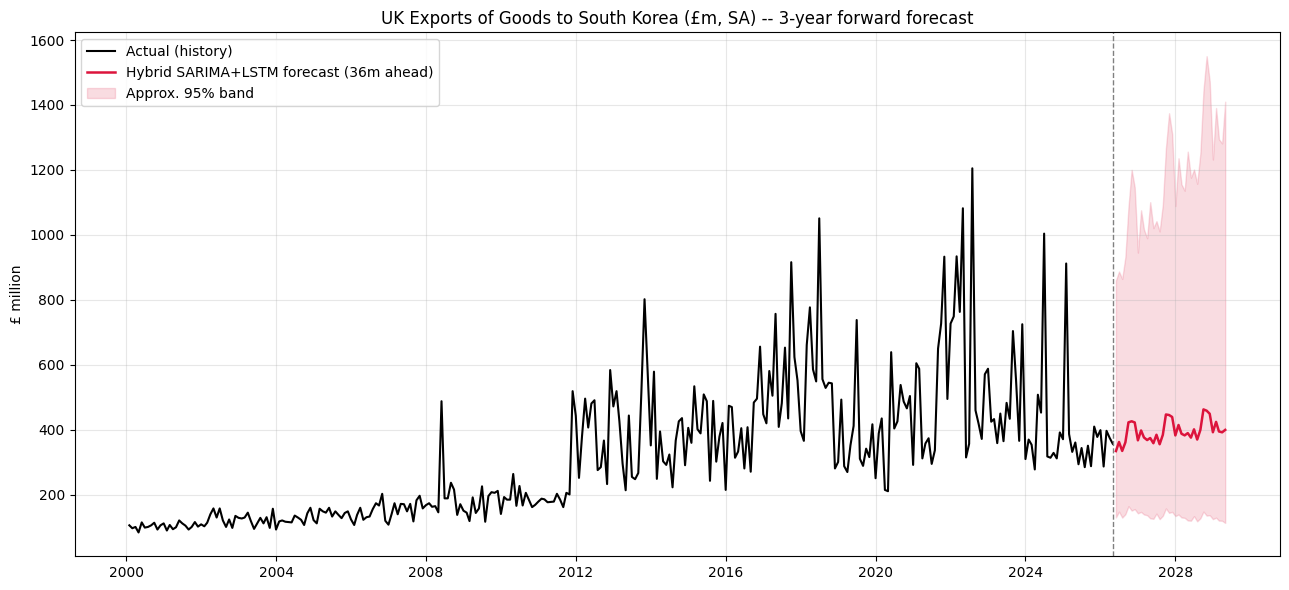

In [31]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(raw.index, raw.values, color="black", lw=1.5, label="Actual (history)")
ax.plot(forecast_level.index, forecast_level.values, color="crimson", lw=1.8,
        label=f"Hybrid SARIMA+LSTM forecast ({FORECAST_HORIZON_TOTAL}m ahead)")
ax.fill_between(forecast_level.index, forecast_lower, forecast_upper,
                 color="crimson", alpha=0.15, label=f"Approx. {int(CI_LEVEL*100)}% band")
ax.axvline(raw.index[-1], color="grey", ls="--", lw=1)
ax.set_title("UK Exports of Goods to South Korea (£m, SA) -- 3-year forward forecast")
ax.set_ylabel("£ million")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()

os.makedirs("outputs", exist_ok=True)
fig.savefig("outputs/future_forecast_36m.png", dpi=150)
forecast_df.to_csv("outputs/future_forecast_36m.csv")
print("Saved: outputs/future_forecast_36m.csv, outputs/future_forecast_36m.png")

### Caveats

- **No held-out ground truth for 2026-2029** -- the honest error expectation for this forecast is the walk-forward RMSE/MAPE by horizon from the "Results" section above, not anything computed here. Since this chains 6 blocks of the model's native 6-month head, error likely compounds across the 36 months similarly to (or worse than) the h=1..6 pattern already seen -- treat months 25-36 as materially less certain than months 1-12.
- **Exogenous features not actually used by this model** -- oil price/ship price are in the feature matrix but the Hybrid/LSTM models only consumes circular month data and SARIMA residual.
- **The confidence band is an approximation, not a rigorous derivation.** It combines (a) a single direct 36-step SARIMA forecast for correctly-growing analytical variance, with (b) the Hybrid model's empirical per-horizon log-RMSE as a stand-in for the LSTM correction's uncertainty.